# XGBoost Feature Importance Evaluation
This notebook cell block analyzes all experiment folders under `experiments/` and visualizes XGBoost feature importance.

What it does:
- Builds Top-10 table per experiment by gain
- Labels each feature as embedding / structural feature / raw feature
- Specifically tags structural features: degree, pagerank, clustering, eigenvector, betweenness, AntiBenford
- Summarizes whether AntiBenford often appears in Top-30 for experiments that enabled it

In [1]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import display

STRUCTURE_ORDER = [
    "degree",
    "pagerank",
    "clustering",
    "eigenvector",
    "betweenness",
    "antibenford",
]

def _load_importance_df(exp_dir: Path) -> pd.DataFrame | None:
    csv_path = exp_dir / "xgboost_feature_importance.csv"
    json_path = exp_dir / "xgboost_feature_importance.json"

    if csv_path.exists():
        df = pd.read_csv(csv_path)
    elif json_path.exists():
        with open(json_path, "r", encoding="utf-8") as f:
            df = pd.DataFrame(json.load(f))
    else:
        return None

    required = {"feature", "gain"}
    if not required.issubset(df.columns):
        return None

    if "weight" not in df.columns:
        df["weight"] = 0
    if "cover" not in df.columns:
        df["cover"] = 0.0

    df = df.copy()
    df["gain"] = pd.to_numeric(df["gain"], errors="coerce").fillna(0.0)
    df["weight"] = pd.to_numeric(df["weight"], errors="coerce").fillna(0).astype(int)
    df["cover"] = pd.to_numeric(df["cover"], errors="coerce").fillna(0.0)
    return df

def _load_feature_flags(exp_dir: Path) -> dict:
    cfg_path = exp_dir / "config.yaml"
    defaults = {name: False for name in STRUCTURE_ORDER}
    if not cfg_path.exists():
        return defaults

    with open(cfg_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}

    data_cfg = cfg.get("data", {}) if isinstance(cfg, dict) else {}
    flags = {
        "degree": bool(data_cfg.get("use_degree", False)),
        "pagerank": bool(data_cfg.get("use_pagerank", False)),
        "clustering": bool(data_cfg.get("use_clustering", False)),
        "eigenvector": bool(data_cfg.get("use_eigenvector", False)),
        "betweenness": bool(data_cfg.get("use_betweenness", False)),
        "antibenford": bool(data_cfg.get("use_antibenford", False)),
    }
    return flags

def _count_orig_features(importance_df: pd.DataFrame) -> int:
    orig_ids = []
    for feat in importance_df["feature"].astype(str):
        if feat.startswith("orig_"):
            try:
                orig_ids.append(int(feat.split("_", 1)[1]))
            except ValueError:
                pass
    return (max(orig_ids) + 1) if orig_ids else 0

def _estimate_base_feature_count(experiments_meta: list[dict]) -> int:
    candidates = []
    for meta in experiments_meta:
        orig_count = meta["orig_count"]
        enabled_count = sum(meta["flags"].values())
        base_candidate = orig_count - enabled_count
        if base_candidate >= 0:
            candidates.append(base_candidate)
    if not candidates:
        return 0
    return int(min(candidates))

def _build_structure_feature_index(flags: dict, base_feature_count: int) -> dict[str, str]:
    mapping = {}
    current_idx = base_feature_count
    for name in STRUCTURE_ORDER:
        if flags.get(name, False):
            mapping[f"orig_{current_idx}"] = name
            current_idx += 1
    return mapping

def _label_feature(feature_name: str, struct_idx_map: dict[str, str]) -> tuple[str, str]:
    feat = str(feature_name)
    if feat.startswith("emb_"):
        return "embedding", "embedding"
    if feat in struct_idx_map:
        return "structure", struct_idx_map[feat]
    if feat.startswith("orig_"):
        return "raw", "raw_feature"
    return "other", "other"

def analyze_xgb_feature_importance(
    experiments_root: str | Path = "../experiments",
    top_k: int = 10,
    anti_top_n: int = 30,
    max_plot_cols: int = 3,
    show_plots: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    experiments_root = Path(experiments_root).resolve()
    if not experiments_root.exists():
        raise FileNotFoundError(f"experiments folder not found: {experiments_root}")

    experiment_dirs = sorted([p for p in experiments_root.iterdir() if p.is_dir()])

    experiments_meta = []
    skipped = []

    for exp_dir in experiment_dirs:
        imp_df = _load_importance_df(exp_dir)
        if imp_df is None or imp_df.empty:
            skipped.append(exp_dir.name)
            continue

        flags = _load_feature_flags(exp_dir)
        orig_count = _count_orig_features(imp_df)
        experiments_meta.append({
            "exp_name": exp_dir.name,
            "path": exp_dir,
            "importance": imp_df,
            "flags": flags,
            "orig_count": orig_count,
        })

    if not experiments_meta:
        raise RuntimeError("No experiment with xgboost feature importance files was found.")

    base_feature_count = _estimate_base_feature_count(experiments_meta)
    print(f"Detected {len(experiments_meta)} experiments with importance files.")
    print(f"Estimated base raw feature count = {base_feature_count}")
    if skipped:
        print(f"Skipped {len(skipped)} folders (no importance files): {', '.join(skipped[:10])}")

    top_rows = []
    anti_rows = []

    n_exp = len(experiments_meta)
    n_cols = min(max_plot_cols, max(1, n_exp))
    n_rows = math.ceil(n_exp / n_cols)

    if show_plots:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
        axes = np.array(axes).reshape(-1)

    for idx, meta in enumerate(experiments_meta):
        exp_name = meta["exp_name"]
        flags = meta["flags"]
        imp = meta["importance"].sort_values("gain", ascending=False).reset_index(drop=True)
        imp["rank"] = np.arange(1, len(imp) + 1)

        struct_map = _build_structure_feature_index(flags, base_feature_count)
        labels = imp["feature"].map(lambda f: _label_feature(f, struct_map))
        imp[["feature_group", "feature_tag"]] = pd.DataFrame(labels.tolist(), index=imp.index)
        imp["experiment"] = exp_name

        top10 = imp.head(top_k).copy()
        top_rows.append(top10)

        anti_feature_name = next((k for k, v in struct_map.items() if v == "antibenford"), None)
        anti_rank = None
        anti_gain = None
        if anti_feature_name is not None:
            anti_row = imp.loc[imp["feature"] == anti_feature_name]
            if not anti_row.empty:
                anti_rank = int(anti_row.iloc[0]["rank"])
                anti_gain = float(anti_row.iloc[0]["gain"])

        anti_rows.append({
            "experiment": exp_name,
            "use_antibenford": bool(flags.get("antibenford", False)),
            "antibenford_feature": anti_feature_name,
            "antibenford_rank": anti_rank,
            "antibenford_gain": anti_gain,
            "in_top_n": bool(anti_rank is not None and anti_rank <= anti_top_n),
            "enabled_structure_features": [k for k, v in flags.items() if v],
        })

        if show_plots:
            ax = axes[idx]
            plot_df = top10.iloc[::-1]
            color_map = {
                "embedding": "#4C78A8",
                "structure": "#F58518",
                "raw": "#54A24B",
                "other": "#B279A2",
            }
            bar_colors = [color_map.get(g, "#888888") for g in plot_df["feature_group"]]
            ax.barh(plot_df["feature"], plot_df["gain"], color=bar_colors)
            ax.set_title(f"{exp_name} | Top-{top_k} gain")
            ax.set_xlabel("gain")
            ax.grid(axis="x", alpha=0.2)

    if show_plots:
        for j in range(len(experiments_meta), len(axes)):
            axes[j].axis("off")
        plt.tight_layout()
        plt.show()

    top10_df = pd.concat(top_rows, ignore_index=True) if top_rows else pd.DataFrame()
    anti_df = pd.DataFrame(anti_rows)

    # Global group summary from top-k
    group_summary = (
        top10_df.groupby(["feature_group", "feature_tag"], dropna=False)
        .agg(
            topk_count=("feature", "count"),
            avg_gain=("gain", "mean"),
        )
        .reset_index()
        .sort_values(["topk_count", "avg_gain"], ascending=[False, False])
    )

    # AntiBenford summary
    anti_enabled = anti_df[anti_df["use_antibenford"]].copy()
    if len(anti_enabled) > 0:
        topn_rate = anti_enabled["in_top_n"].mean() * 100
        median_rank = anti_enabled["antibenford_rank"].median(skipna=True)
        print()
        print("AntiBenford Summary")
        print("-------------------")
        print(f"Experiments with AntiBenford enabled: {len(anti_enabled)}")
        print(f"AntiBenford in Top-{anti_top_n}: {topn_rate:.1f}%")
        print(f"AntiBenford median rank: {median_rank}")
    else:
        print()
        print("AntiBenford Summary")
        print("-------------------")
        print("No experiment has use_antibenford=True in config.yaml")

    return top10_df, group_summary, anti_df

Detected 7 experiments with importance files.
Estimated base raw feature count = 165
Skipped 2 folders (no importance files): __pycache__, exp_7_GraphSAGE_e2e_hd64


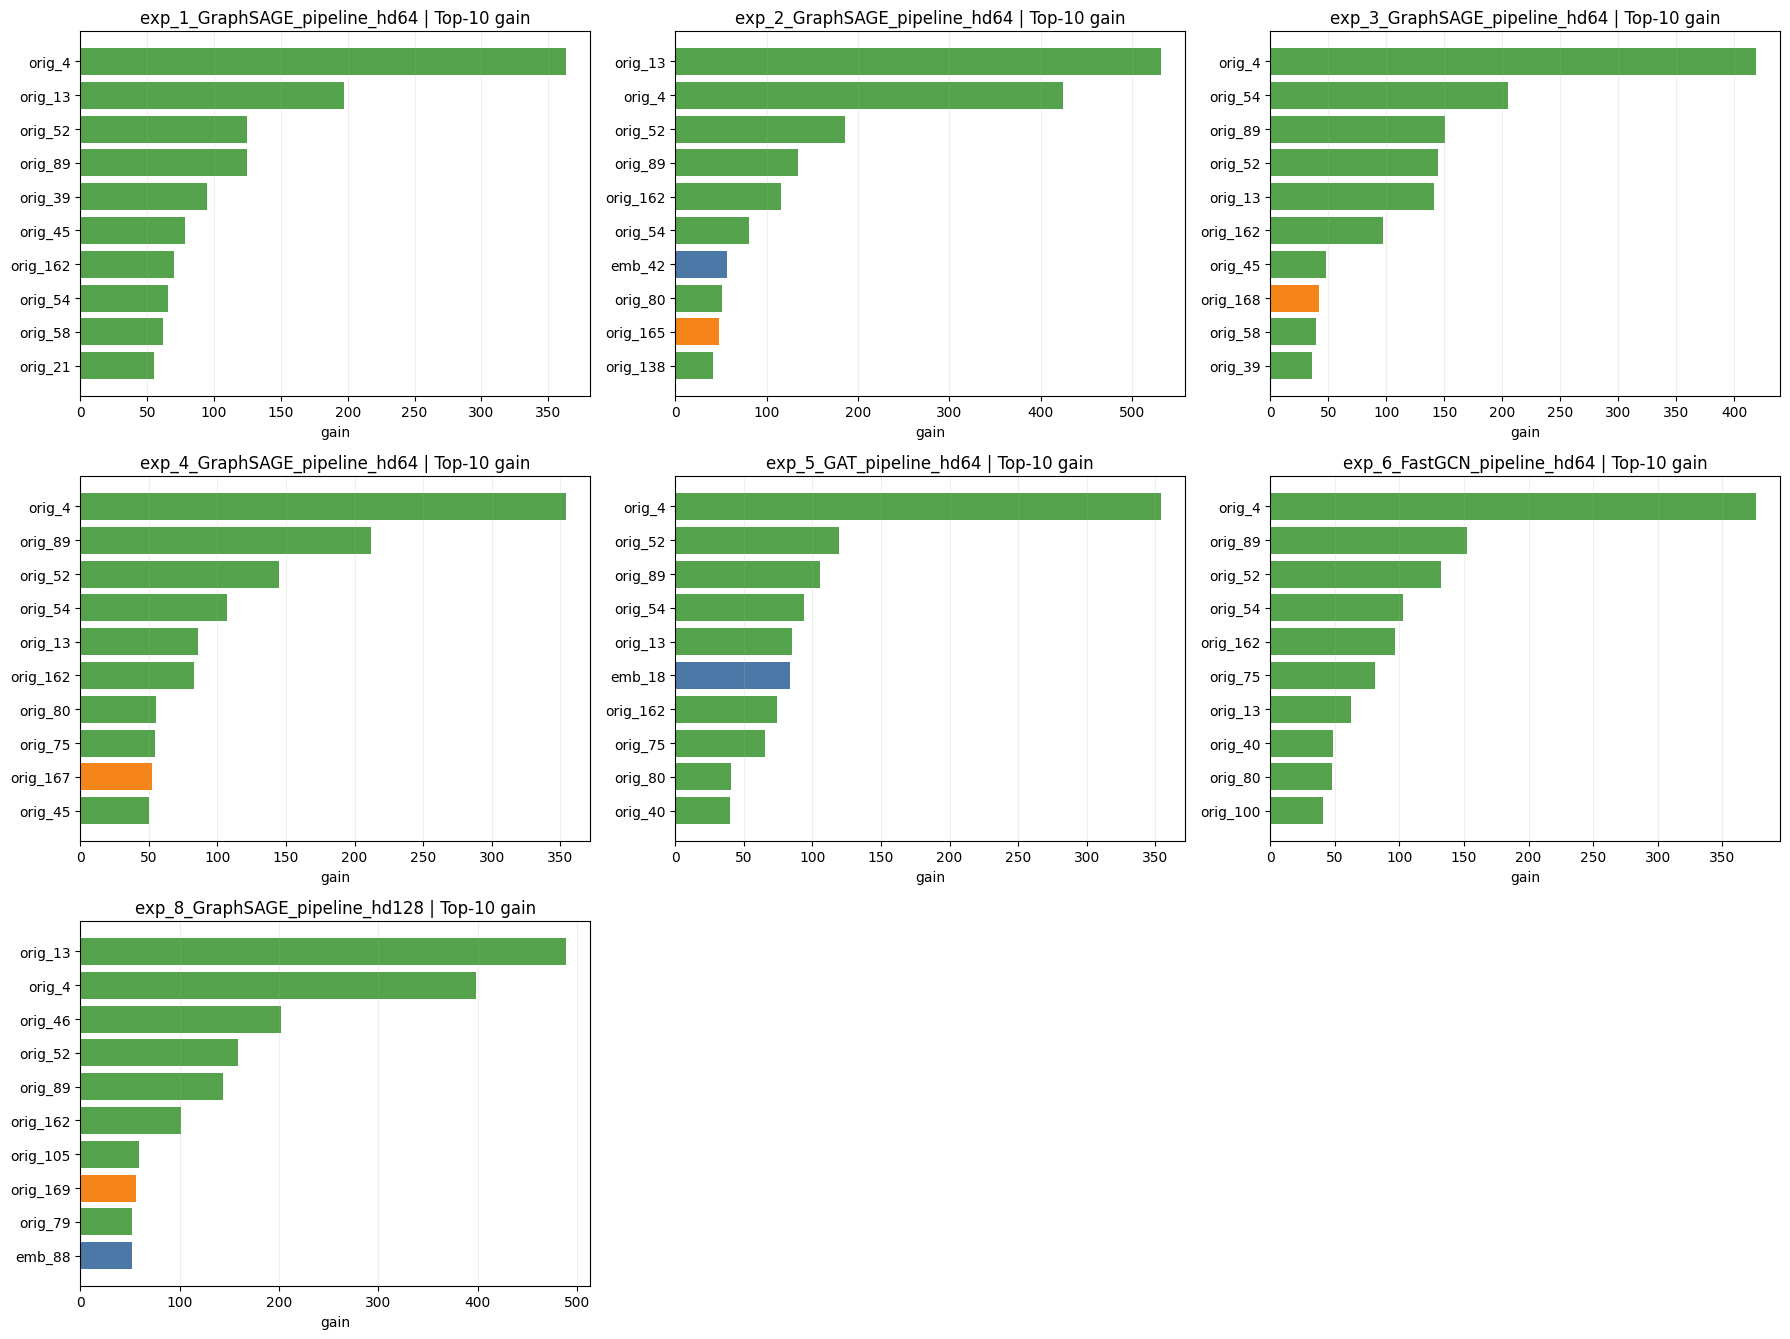


AntiBenford Summary
-------------------
Experiments with AntiBenford enabled: 6
AntiBenford in Top-30: 100.0%
AntiBenford median rank: 9.0

Top-10 table (all experiments, sorted by experiment/rank):


,experiment,rank,feature,gain,feature_group,feature_tag,weight,cover
0,exp_1_GraphSAGE_pipeline_hd64,1,orig_4,363.036255,raw,raw_feature,22,353.549164
1,exp_1_GraphSAGE_pipeline_hd64,2,orig_13,197.473846,raw,raw_feature,1,446.377106
2,exp_1_GraphSAGE_pipeline_hd64,3,orig_52,124.894745,raw,raw_feature,137,263.751709
3,exp_1_GraphSAGE_pipeline_hd64,4,orig_89,124.862259,raw,raw_feature,66,196.906754
4,exp_1_GraphSAGE_pipeline_hd64,5,orig_39,95.007423,raw,raw_feature,24,270.873077
...,...,...,...,...,...,...,...,...
65,exp_8_GraphSAGE_pipeline_hd128,6,orig_162,101.776863,raw,raw_feature,31,169.616058
66,exp_8_GraphSAGE_pipeline_hd128,7,orig_105,58.974895,raw,raw_feature,20,49.693916
67,exp_8_GraphSAGE_pipeline_hd128,8,orig_169,56.294281,structure,antibenford,57,497.114014
68,exp_8_GraphSAGE_pipeline_hd128,9,orig_79,52.316219,raw,raw_feature,15,158.017990



Feature-group summary from Top-10 tables:


,feature_group,feature_tag,topk_count,avg_gain
1,raw,raw_feature,63,142.045496
2,structure,antibenford,4,49.673653
0,embedding,embedding,3,63.854253



AntiBenford ranking summary:


,experiment,use_antibenford,antibenford_feature,antibenford_rank,antibenford_gain,in_top_n
0,exp_2_GraphSAGE_pipeline_hd64,True,orig_165,9.0,48.042717,True
1,exp_3_GraphSAGE_pipeline_hd64,True,orig_168,8.0,41.907635,True
2,exp_4_GraphSAGE_pipeline_hd64,True,orig_167,9.0,52.449978,True
3,exp_5_GAT_pipeline_hd64,True,orig_167,12.0,29.042971,True
4,exp_6_FastGCN_pipeline_hd64,True,orig_167,11.0,40.519413,True
5,exp_8_GraphSAGE_pipeline_hd128,True,orig_169,8.0,56.294281,True
6,exp_1_GraphSAGE_pipeline_hd64,False,NaN,NaN,NaN,False


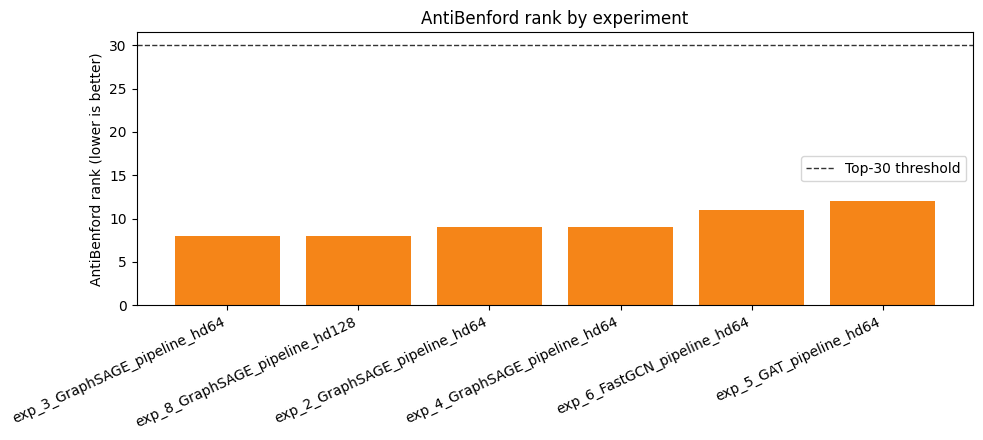


Conclusion about AntiBenford:
- AntiBenford appears in Top-30 in 100.0% of enabled experiments.
- Median rank is 9.0 (lower rank means stronger importance).
- This supports that AntiBenford is not just noise; it contributes as a domain feature.


In [3]:
# Run analysis on all experiment folders and display requested outputs
top10_df, group_summary_df, anti_df = analyze_xgb_feature_importance(
    experiments_root="../experiments",
    top_k=10,
    anti_top_n=30,
    max_plot_cols=3,
    show_plots=True,
)

print("\nTop-10 table (all experiments, sorted by experiment/rank):")
top10_view = top10_df[[
    "experiment", "rank", "feature", "gain", "feature_group", "feature_tag", "weight", "cover"
]].sort_values(["experiment", "rank"]).reset_index(drop=True)
display(top10_view)

print("\nFeature-group summary from Top-10 tables:")
display(group_summary_df)

print("\nAntiBenford ranking summary:")
anti_view = anti_df[[
    "experiment",
    "use_antibenford",
    "antibenford_feature",
    "antibenford_rank",
    "antibenford_gain",
    "in_top_n",
]].sort_values(["use_antibenford", "experiment"], ascending=[False, True]).reset_index(drop=True)
display(anti_view)

anti_enabled = anti_df[anti_df["use_antibenford"]].copy()
if len(anti_enabled) > 0:
    anti_plot = anti_enabled.dropna(subset=["antibenford_rank"]).sort_values("antibenford_rank")
    if not anti_plot.empty:
        plt.figure(figsize=(10, 4.5))
        colors = ["#F58518" if r <= 30 else "#E45756" for r in anti_plot["antibenford_rank"]]
        plt.bar(anti_plot["experiment"], anti_plot["antibenford_rank"], color=colors)
        plt.axhline(30, color="#333333", linestyle="--", linewidth=1, label="Top-30 threshold")
        plt.ylabel("AntiBenford rank (lower is better)")
        plt.title("AntiBenford rank by experiment")
        plt.xticks(rotation=25, ha="right")
        plt.legend()
        plt.tight_layout()
        plt.show()

    hit_rate = anti_enabled["in_top_n"].mean() * 100
    median_rank = anti_enabled["antibenford_rank"].median(skipna=True)
    print()
    print("Conclusion about AntiBenford:")
    print(f"- AntiBenford appears in Top-30 in {hit_rate:.1f}% of enabled experiments.")
    print(f"- Median rank is {median_rank:.1f} (lower rank means stronger importance).")
    if hit_rate >= 50:
        print("- This supports that AntiBenford is not just noise; it contributes as a domain feature.")
    else:
        print("- Contribution exists but may depend on model/feature combinations.")
else:
    print("\nNo AntiBenford-enabled experiments found in experiments folder.")